In [118]:
library(ggplot2)
library(dplyr)

options(repr.plot.width=36/25.4,repr.plot.height=36/25.4,repr.plot.res=300)

In [ ]:
# "indir" is a custom input path, and "outdir" is a custom output path.
# indir=""
# outdir=""

In [ ]:
selected_loops=read.csv(paste0(indir,'/selected_loops.csv'))

In [3]:
dim(selected_loops);head(selected_loops)

[1] 31704     8

,bin_intergenic,bin_gene,chromosome,bin_intergenic_in_chromosome,gene_id,PCC_3C_RNA,bin_distance,PCC_5hmCG_RNA
,<int>,<int>,<chr>,<int>,<chr>,<dbl>,<int>,<dbl>
1,463,504,chr1,463,ENSMUSG00000002459.17,-0.20726372,41,-0.15418849
2,641,685,chr1,641,ENSMUSG00000033740.17,0.08479841,44,-0.30560963
3,1024,1043,chr1,1024,ENSMUSG00000042501.12,-0.27949825,19,-0.30778747
4,1083,1113,chr1,1083,ENSMUSG00000048960.13,0.38296159,30,0.04769515
5,1083,1125,chr1,1083,ENSMUSG00000048960.13,0.38296159,42,0.04769515
6,1198,1166,chr1,1198,ENSMUSG00000057715.13,0.45005256,32,0.58763418


In [109]:
selected_loops$'loop_distance' = 10*selected_loops$'bin_distance'
head(selected_loops)

,bin_intergenic,bin_gene,chromosome,bin_intergenic_in_chromosome,gene_id,PCC_3C_RNA,bin_distance,PCC_5hmCG_RNA,loop_distance
,<int>,<int>,<chr>,<int>,<chr>,<dbl>,<int>,<dbl>,<dbl>
1,463,504,chr1,463,ENSMUSG00000002459.17,-0.20726372,41,-0.15418849,410
2,641,685,chr1,641,ENSMUSG00000033740.17,0.08479841,44,-0.30560963,440
3,1024,1043,chr1,1024,ENSMUSG00000042501.12,-0.27949825,19,-0.30778747,190
4,1083,1113,chr1,1083,ENSMUSG00000048960.13,0.38296159,30,0.04769515,300
5,1083,1125,chr1,1083,ENSMUSG00000048960.13,0.38296159,42,0.04769515,420
6,1198,1166,chr1,1198,ENSMUSG00000057715.13,0.45005256,32,0.58763418,320


In [110]:
# Calculate quantiles for smoothed lines
quantiles_smooth <- selected_loops %>%
  group_by(loop_distance) %>%
  summarise(
    y_25 = quantile(PCC_3C_RNA, 0.25),
    y_50 = quantile(PCC_3C_RNA, 0.50),
    y_75 = quantile(PCC_3C_RNA, 0.75)
  ) %>%
  ungroup() %>%
  mutate(
    y_25_smooth = predict(loess(y_25 ~ loop_distance, data = ., span = 0.75)),
    y_50_smooth = predict(loess(y_50 ~ loop_distance, data = ., span = 0.75)),
    y_75_smooth = predict(loess(y_75 ~ loop_distance, data = ., span = 0.75)) )

In [111]:
quantiles_smooth

loop_distance,y_25,y_50,y_75,y_25_smooth,y_50_smooth,y_75_smooth
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
20,-0.08409621,0.140617259,0.37450761,-0.1646054,0.0919371455,0.3734601
30,-0.27449338,-0.011191135,0.36335636,-0.1522788,0.1117428357,0.3908405
40,-0.16876499,0.061790704,0.32508224,-0.1417115,0.1293774356,0.4064792
50,-0.18170471,0.163506054,0.41200828,-0.1329683,0.1447719039,0.4203323
60,-0.13570501,0.150560321,0.45422030,-0.1261140,0.1578571995,0.4323558
70,-0.13532568,0.202225215,0.47811896,-0.1212138,0.1685642810,0.4425058
80,-0.08543242,0.196862873,0.49526117,-0.1183324,0.1768241073,0.4507384
90,-0.03262539,0.263509843,0.50597949,-0.1176685,0.1824224323,0.4569129
100,-0.06516750,0.244306334,0.50833350,-0.1191864,0.1853941069,0.4610491


In [112]:
merged_data <- selected_loops %>%
  left_join(quantiles_smooth, by = "loop_distance")


In [113]:
merged_data

bin_intergenic,bin_gene,chromosome,bin_intergenic_in_chromosome,gene_id,PCC_3C_RNA,bin_distance,PCC_5hmCG_RNA,loop_distance,y_25,y_50,y_75,y_25_smooth,y_50_smooth,y_75_smooth
<int>,<int>,<chr>,<int>,<chr>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
463,504,chr1,463,ENSMUSG00000002459.17,-0.207263723,41,-0.154188489,410,-0.46181044,-0.186689939,0.15234469,-0.4412348,-0.1741477231,0.1536804
641,685,chr1,641,ENSMUSG00000033740.17,0.084798407,44,-0.305609626,440,-0.45256720,-0.215818107,0.08028974,-0.4522061,-0.1957082574,0.1319304
1024,1043,chr1,1024,ENSMUSG00000042501.12,-0.279498250,19,-0.307787467,190,-0.22701401,0.108331596,0.43020133,-0.2215872,0.1045120730,0.4133611
1083,1113,chr1,1083,ENSMUSG00000048960.13,0.382961587,30,0.047695152,300,-0.36200904,-0.038788033,0.27712426,-0.3770020,-0.0626341909,0.2725880
1083,1125,chr1,1083,ENSMUSG00000048960.13,0.382961587,42,0.047695152,420,-0.44914631,-0.190073945,0.12191103,-0.4452030,-0.1818283759,0.1458497
1198,1166,chr1,1198,ENSMUSG00000057715.13,0.450052557,32,0.587634178,320,-0.38502782,-0.081584781,0.25699730,-0.3911015,-0.0843250765,0.2490696
1213,1168,chr1,1213,ENSMUSG00000057715.13,-0.279460615,45,0.538987336,450,-0.44885918,-0.213153110,0.10407574,-0.4552607,-0.2018644688,0.1259141
1258,1280,chr1,1258,ENSMUSG00000016918.15,-0.167982953,22,0.066002325,220,-0.30211201,-0.003288413,0.33834722,-0.2734007,0.0545296980,0.3767571
1310,1272,chr1,1310,ENSMUSG00000016918.15,-0.199195000,38,0.032305397,380,-0.41994894,-0.115710606,0.18930067,-0.4272106,-0.1486172936,0.1798521


In [163]:
p <- ggplot(merged_data, aes(x = loop_distance, y = PCC_3C_RNA)) +
# geom_boxplot(mapping=aes(group=bin_distance, y=PCC_3C_RNA))+
  geom_ribbon(aes(ymin = y_25_smooth, ymax = y_75_smooth), fill = "cadetblue2", alpha = 0.4)+
  geom_smooth(se = FALSE,color='deepskyblue2') +  # Smooth line  
labs(title = "",
       x = "loop distance (kb)",
       y = "PCC(3C interaction, RNA)") +
  theme_minimal() +
  theme(
    text = element_text(size = 5),
    axis.line.x = element_line(color = "black"),
    axis.line.y = element_line(color = "black"),
    axis.text = element_text(color = "black",family="ArialMT"),
    axis.title.x = element_text(color="black", size=6,family="ArialMT"),
    axis.title.y = element_text(color="black", size=6,family="ArialMT"),
    axis.text.x = element_text(color="black", size=5,family="ArialMT", hjust = 0.5,),
    axis.text.y = element_text(color="black", size=5,family="ArialMT"),
    axis.ticks = element_line(color = "black"),
    strip.text = element_text(color = "black",family="ArialMT"),
    plot.title = element_text(hjust = 0.5, color = "black",family="ArialMT")
  ) 

`geom_smooth()` using method = 'gam' and formula = 'y ~ s(x, bs = "cs")'


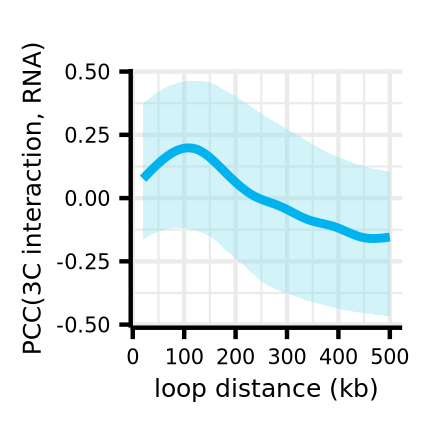

In [164]:
p

In [ ]:
pdf('../../../../output/01-youth/06-m3C_supplementary_figures/04_lineplot_distance_PCC(3C,RNA).pdf', width=36/25.4,height=36/25.4, family="ArialMT")
print(p)
dev.off()

`geom_smooth()` using method = 'gam' and formula = 'y ~ s(x, bs = "cs")'


pdf 
  2